# FIR Design, Windows, and Precision

This notebook walks through FIR filter design via the window method and then applies the same mixed-precision workflow used in `02_iir_precision.ipynb` to finite-impulse-response filters.

Unlike IIR filters, FIRs have no poles — so `stability_margin`, `condition_number`, and `pole_displacement` don't apply. But the three-scalar template (taps, state, samples) still lets us see how coefficient and accumulation precision affect the filtered output.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mpdsp
from mpdsp.filters import compare_filters, plot_filter_comparison

SAMPLE_RATE = 8000.0

## Designing a lowpass via the window method

`fir_lowpass(num_taps, sample_rate, cutoff, window)` designs linear-phase FIR taps by windowing a truncated sinc. Odd `num_taps` yields a type-I linear-phase filter (symmetric, integer group delay).

num_taps = 51


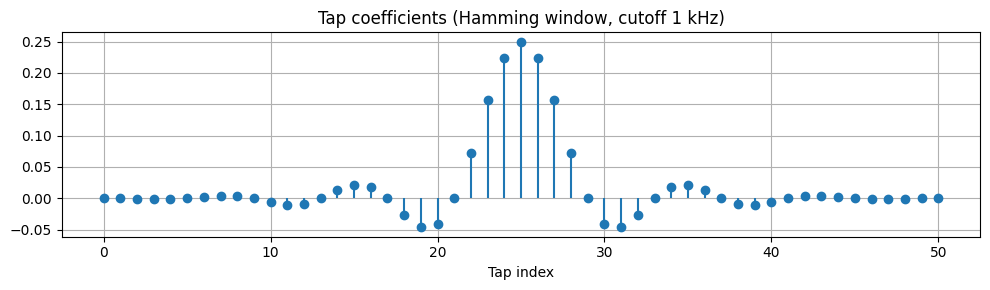

In [2]:
fir = mpdsp.fir_lowpass(num_taps=51, sample_rate=SAMPLE_RATE, cutoff=1000.0)
print(f'num_taps = {fir.num_taps()}')

fig, ax = plt.subplots(figsize=(10, 3))
ax.stem(fir.coefficients(), basefmt=' ')
ax.set_title('Tap coefficients (Hamming window, cutoff 1 kHz)')
ax.set_xlabel('Tap index')
ax.grid(True)
fig.tight_layout();

The symmetric shape is what gives the filter its linear phase. The main lobe's width sets the transition bandwidth; the side-lobe envelope — fixed by the window — sets stopband attenuation.

## Comparing windows

Each window trades transition width against stopband attenuation. Overlaying the six available windows at a fixed cutoff makes the trade-off visible.

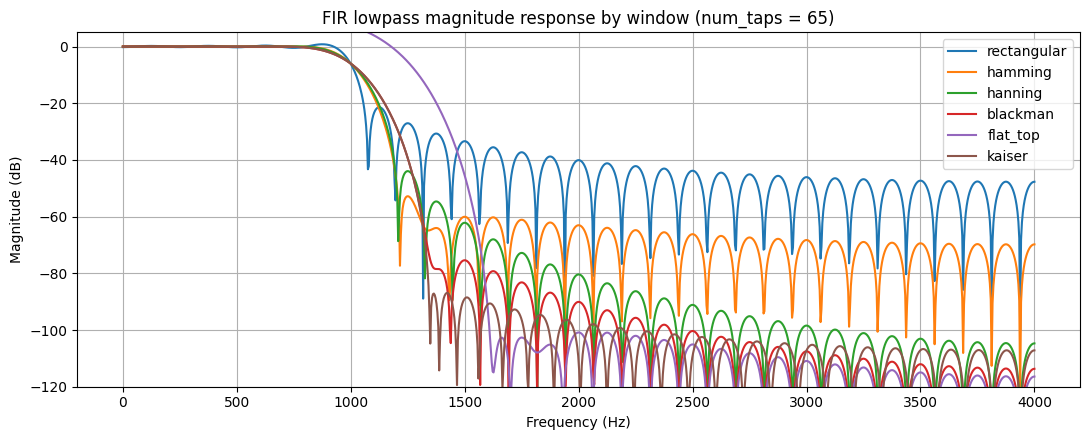

In [3]:
windows = ['rectangular', 'hamming', 'hanning', 'blackman', 'flat_top', 'kaiser']
num_taps = 65

freqs = np.linspace(0.0, 0.5, 1024)
fig, ax = plt.subplots(figsize=(11, 4.5))
for w in windows:
    f = mpdsp.fir_lowpass(num_taps=num_taps, sample_rate=SAMPLE_RATE,
                          cutoff=1000.0, window=w)
    H = f.frequency_response(freqs)
    ax.plot(freqs * SAMPLE_RATE, 20 * np.log10(np.maximum(np.abs(H), 1e-12)), label=w)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (dB)')
ax.set_title(f'FIR lowpass magnitude response by window (num_taps = {num_taps})')
ax.set_ylim(-120, 5)
ax.legend()
ax.grid(True)
fig.tight_layout();

- **Rectangular**: sharpest transition, worst stopband (the textbook Gibbs ripple).
- **Hamming / Hanning**: the usual default — good balance.
- **Blackman**: quieter stopband, wider transition.
- **Flat_top**: designed for amplitude accuracy on tones, not stopband — don't use it as a general-purpose antialiasing filter.
- **Kaiser**: tunable via `kaiser_beta` — the one to reach for when you want to dial in a specific stopband attenuation.

## The four FIR response types

Lowpass and highpass are one-parameter designs; bandpass and bandstop take two frequencies. Bandstop is built via spectral inversion of a bandpass (the upstream C++ library doesn't ship a direct bandstop design).

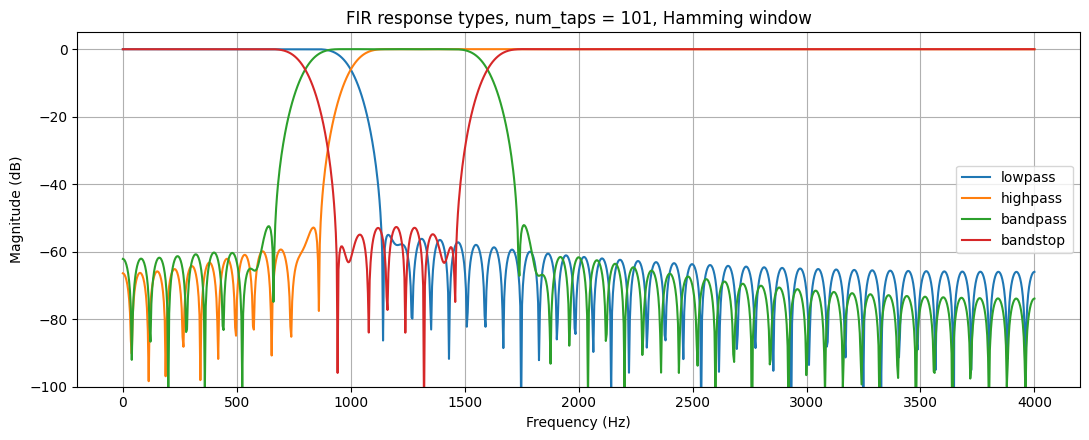

In [4]:
filters = {
    'lowpass':  mpdsp.fir_lowpass(num_taps=101, sample_rate=SAMPLE_RATE, cutoff=1000.0),
    'highpass': mpdsp.fir_highpass(num_taps=101, sample_rate=SAMPLE_RATE, cutoff=1000.0),
    'bandpass': mpdsp.fir_bandpass(num_taps=101, sample_rate=SAMPLE_RATE, f_low=800.0, f_high=1600.0),
    'bandstop': mpdsp.fir_bandstop(num_taps=101, sample_rate=SAMPLE_RATE, f_low=800.0, f_high=1600.0),
}

fig, ax = plt.subplots(figsize=(11, 4.5))
for name, f in filters.items():
    H = f.frequency_response(freqs)
    ax.plot(freqs * SAMPLE_RATE, 20 * np.log10(np.maximum(np.abs(H), 1e-12)), label=name)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (dB)')
ax.set_title('FIR response types, num_taps = 101, Hamming window')
ax.set_ylim(-100, 5)
ax.legend()
ax.grid(True)
fig.tight_layout();

## Explicit-coefficient construction

`fir_filter(coefficients)` wraps any tap vector. A delta at index zero is a pure pass-through — useful as a sanity check.

In [5]:
delta_taps = np.zeros(21)
delta_taps[0] = 1.0
pass_through = mpdsp.fir_filter(delta_taps)

t = np.arange(1024) / SAMPLE_RATE
x = np.sin(2 * np.pi * 500 * t)
y = pass_through.process(x)

print('Pass-through max error:', np.max(np.abs(y - x)))

Pass-through max error: 0.0


## Mixed-precision sweep

Same workflow as the IIR notebook: run the signal through the filter at each pre-instantiated dtype, measure SQNR and max error.

In [6]:
t = np.arange(4096) / SAMPLE_RATE
signal = np.sin(2 * np.pi * 200 * t) + 0.5 * np.sin(2 * np.pi * 3000 * t)

fir_lp = mpdsp.fir_lowpass(num_taps=101, sample_rate=SAMPLE_RATE, cutoff=1000.0)
compare_filters(fir_lp, signal)

,dtype,sqnr_db,max_abs_error,max_rel_error,error
0,reference,300.000000,0.000000e+00,0.000000e+00,None
1,gpu_baseline,138.000036,2.664019e-07,2.664350e-07,None
2,ml_hw,73.549740,3.640335e-04,3.640788e-04,None
3,cf24,105.779342,9.266703e-06,9.267855e-06,None
4,half,58.219789,2.805440e-03,2.805788e-03,None
5,posit_full,88.459997,9.240598e-05,9.241746e-05,None
6,tiny_posit,24.330581,8.845068e-02,8.846167e-02,None


FIRs are notably more quantization-tolerant than high-order IIRs. Because each tap acts independently on the input — there's no recursive state — coefficient errors don't compound the way pole displacements do. Compare these SQNR numbers to the Chebyshev / Elliptic rows in `02_iir_precision.ipynb`.

## FIR vs IIR at matched selectivity

The classic FIR / IIR trade-off: match the stopband attenuation and see how many multiplies each form needs.

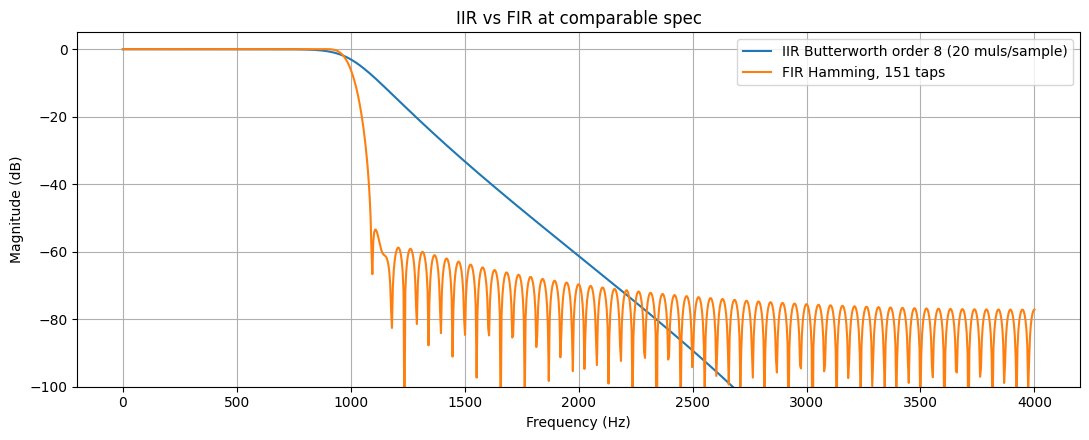

In [7]:
iir = mpdsp.butterworth_lowpass(order=8, sample_rate=SAMPLE_RATE, cutoff=1000.0)
fir_match = mpdsp.fir_lowpass(num_taps=151, sample_rate=SAMPLE_RATE, cutoff=1000.0)

freqs = np.linspace(0.0, 0.5, 1024)
Hiir = 20 * np.log10(np.maximum(np.abs(iir.frequency_response(freqs)), 1e-12))
Hfir = 20 * np.log10(np.maximum(np.abs(fir_match.frequency_response(freqs)), 1e-12))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(freqs * SAMPLE_RATE, Hiir, label=f'IIR Butterworth order 8 ({iir.num_stages()*5} muls/sample)')
ax.plot(freqs * SAMPLE_RATE, Hfir, label=f'FIR Hamming, {fir_match.num_taps()} taps')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (dB)')
ax.set_title('IIR vs FIR at comparable spec')
ax.set_ylim(-100, 5)
ax.legend()
ax.grid(True)
fig.tight_layout();

## Takeaways

- **Window choice is a design parameter, not a preference.** Pick based on whether you care more about transition width or stopband attenuation.
- **FIRs are forgiving of low precision** — no feedback means no pole to quantize, so mixed-precision sweeps typically show much higher SQNR than the equivalent IIR.
- **The cost is arithmetic:** matching a Butterworth's stopband can need 100+ taps, but those taps can run at lower precision than the IIR's coefficients would tolerate.
- The same `compare_filters` / `plot_filter_comparison` helpers work for both filter kinds, so mixed IIR+FIR cascades can be swept in one consistent notebook.